# VQCFD Gradient and Legacy Variance Analysis

The reusable loading and plotting functions live in `analysis.py`. The first section remains available for old variance-mode results; the new raw-gradient workflow is below.


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover legacy variance runs


In [2]:
variance_runs = an.discover_variance_runs()
an.print_variance_runs(variance_runs)


count= 0


## Select runs


In [3]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
RUNS = [
    # ("var", "N2L1"),
    # ("var", "N3L1"),
]

# Each entry replaces its source runs with one variance computed from all raw gradient samples.
VARIANCE_COMBINATIONS = {
    "combined_N10L1": [("var", f"N10L1_{i}") for i in range(1, 5)],
    "combined_N10L2": [("var", f"N10L2_{i}") for i in range(1, 5)],
}

selected = [an.load_variance_run(d, label) for d, label in RUNS] if RUNS else variance_runs
selected = an.apply_variance_combinations(selected, VARIANCE_COMBINATIONS)
an.print_variance_runs(selected)
an.variance_table(selected)


count= 0


,full_label,n,l,circuit,variance,variance_tries,variance_num_samples,variance_runtime_s,gradient_mean,combined_from


## Variance plots


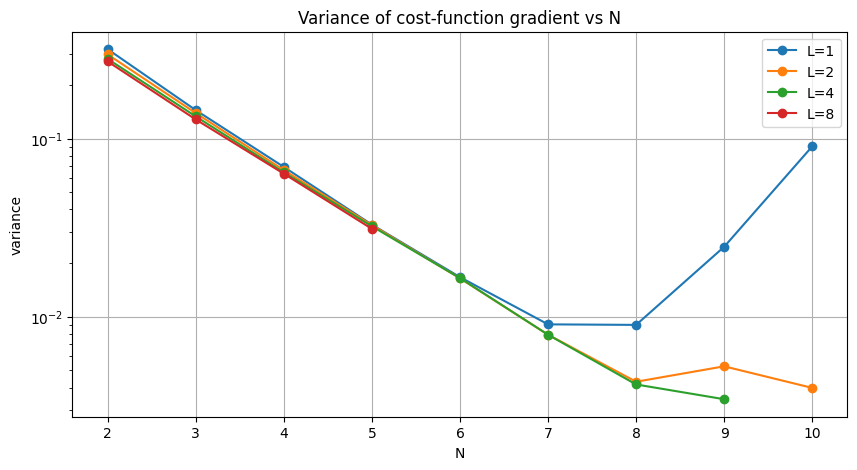

In [6]:
an.plot_variance_vs_n(selected, log_y=True);


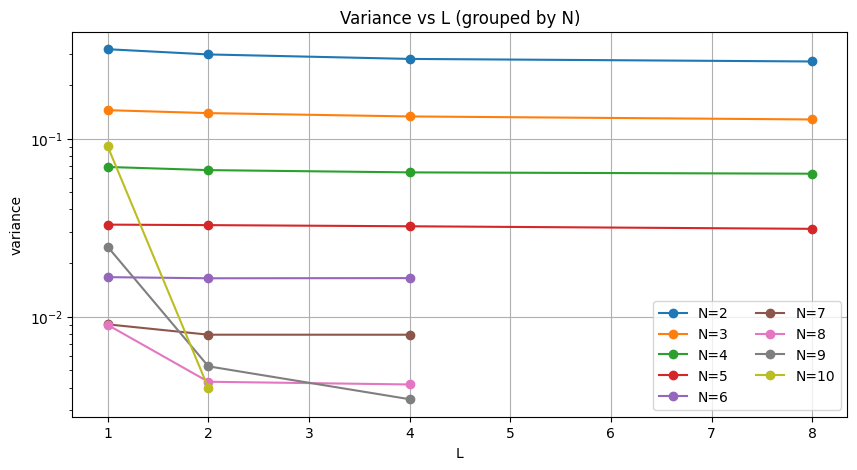

In [12]:
an.plot_variance_vs_l(selected, log_y=True);


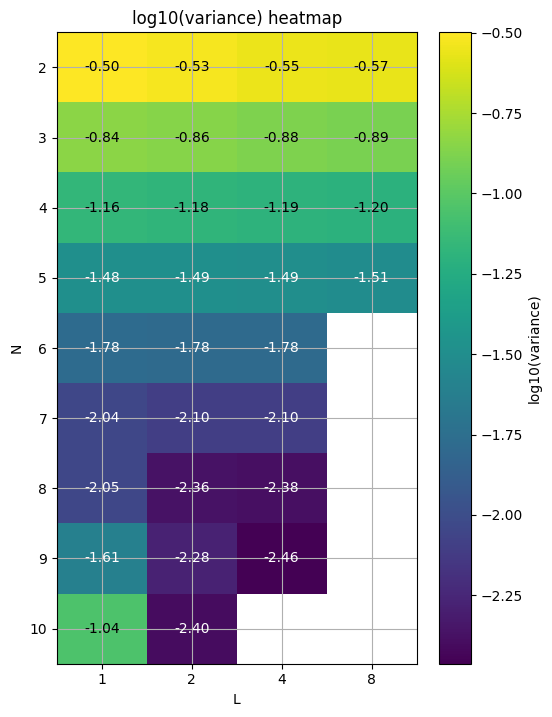

In [6]:
an.plot_variance_heatmap(selected);


## Inspect one run


In [5]:
if selected:
    selected[0]["values"]


## Discover and select gradient runs

Each run contains one raw derivative tensor with axes `(five circuits, parameters, random sweeps)`. Total-cost and contribution gradients are reconstructed from it during analysis.


In [4]:
gradient_runs = an.discover_gradient_runs()
an.print_gradient_runs(gradient_runs)


grad_N2L1                        N=2   L=1   circuit=default              gradients=20000/20000
grad_N2L1_brickwork_ring_ry      N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_mixed_sine_modes N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_positive_periodic_wave N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_tapered_gaussian N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_mixed_sine_modes       N=2   L=1   circuit=default              gradients=20000/20000
grad_N2L1_multiscale_tree        N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_mixed_sine_modes N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_positive_periodic_wave N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_tapered_gaussian N=2   L=1   circuit=multi

In [5]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
GRADIENT_RUNS = [
    # ("grad", "N2L1"),
    # ("grad", "N3L1"),
]

selected_gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_RUNS]
    if GRADIENT_RUNS else gradient_runs
)
an.print_gradient_runs(selected_gradient_runs)


grad_N2L1                        N=2   L=1   circuit=default              gradients=20000/20000
grad_N2L1_brickwork_ring_ry      N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_mixed_sine_modes N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_positive_periodic_wave N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_brickwork_ring_ry_tapered_gaussian N=2   L=1   circuit=brickwork_ring_ry    gradients=20000/20000
grad_N2L1_mixed_sine_modes       N=2   L=1   circuit=default              gradients=20000/20000
grad_N2L1_multiscale_tree        N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_mixed_sine_modes N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_positive_periodic_wave N=2   L=1   circuit=multiscale_tree      gradients=20000/20000
grad_N2L1_multiscale_tree_tapered_gaussian N=2   L=1   circuit=multi

## Statistics over all parameters

The unprefixed `mean_gradient`, `mean_gradient_norm`, and `variance` columns describe the reconstructed total-cost gradient. The next 24 columns contain the same three statistics for contributions 1–3 and circuits 1–5. The three prefactor-free contributions are `dc1`, `dc2 - 2*dc1 + dc3`, and `dc4 - dc5`.


In [6]:
gradient_run_stats = an.gradient_run_table(selected_gradient_runs)
gradient_run_stats


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance,gradient_runtime_s
0,grad_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,-0.013498,0.488014,0.062934,-0.010535,0.243027,0.015555,-0.001266,0.242353,0.015568,2386.390542
1,grad_N2L1_brickwork_ring_ry,2,1,brickwork_ring_ry,sine,0.01,0.01,0.333333,0.0009,4,...,-0.016198,0.483851,0.061818,-0.009903,0.242069,0.015462,-0.001480,0.242787,0.015617,2426.914363
2,grad_N2L1_brickwork_ring_ry_mixed_sine_modes,2,1,brickwork_ring_ry,mixed_sine_modes,0.01,0.01,0.333333,0.0009,4,...,-0.015510,0.485030,0.062133,-0.010138,0.242756,0.015548,0.000278,0.243879,0.015776,2416.174094
3,grad_N2L1_brickwork_ring_ry_positive_periodic_...,2,1,brickwork_ring_ry,positive_periodic_wave,0.01,0.01,0.333333,0.0009,4,...,-0.008468,0.484815,0.062755,-0.003177,0.187341,0.009433,0.005924,0.188834,0.009426,2423.913206
4,grad_N2L1_brickwork_ring_ry_tapered_gaussian,2,1,brickwork_ring_ry,tapered_gaussian,0.01,0.01,0.333333,0.0009,4,...,0.012530,0.484493,0.062101,0.010166,0.241281,0.015375,0.000784,0.242780,0.015630,2420.647432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,grad_N8L2,8,2,default,sine,0.01,0.01,0.003922,6.5025,24,...,-0.000395,0.133775,0.000965,0.000013,0.010332,0.000006,0.000013,0.010317,0.000006,70866.775473
219,grad_N8L4,8,4,default,sine,0.01,0.01,0.003922,6.5025,40,...,0.000735,0.186304,0.000971,0.000015,0.013940,0.000006,0.000016,0.013939,0.000006,72887.749931
220,grad_N9L1,9,1,default,sine,0.01,0.01,0.001957,26.1121,18,...,0.000291,0.075989,0.000500,-0.000021,0.003987,0.000001,-0.000022,0.003982,0.000001,415262.472853
221,grad_N9L2,9,2,default,sine,0.01,0.01,0.001957,26.1121,27,...,0.000342,0.097808,0.000473,-0.000032,0.005346,0.000001,-0.000032,0.005353,0.000001,596412.960334


## Statistics for each parameter

For a single scalar parameter, its gradient norm is its absolute value, so `mean_gradient_norm` is the mean absolute gradient.


In [7]:
gradient_parameter_stats = an.gradient_parameter_table(selected_gradient_runs)
gradient_parameter_stats


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_2_variance,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance
0,grad_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.059913,-0.062594,0.213894,0.060441,-0.045371,0.106425,0.013965,-0.003989,0.104509,0.015470
1,grad_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.063641,-0.050464,0.207006,0.058670,0.001721,0.103845,0.015278,-0.002584,0.103952,0.015427
2,grad_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.057379,0.001989,0.213481,0.064340,-0.000815,0.106248,0.015912,0.002323,0.104590,0.015440
3,grad_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.063163,0.057075,0.209494,0.059286,0.002323,0.104590,0.015440,-0.000815,0.106248,0.015912
4,grad_N2L1_brickwork_ring_ry,2,1,brickwork_ring_ry,sine,0.01,0.01,0.333333,0.0009,4,...,0.060958,-0.057664,0.211297,0.059338,-0.039282,0.102466,0.013530,-0.003043,0.106476,0.015975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4652,grad_N9L4,9,4,default,sine,0.01,0.01,0.001957,26.1121,45,...,0.000423,0.004254,0.015322,0.000426,0.000008,0.000896,0.000001,0.000010,0.000895,0.000001
4653,grad_N9L4,9,4,default,sine,0.01,0.01,0.001957,26.1121,45,...,0.000503,0.001310,0.016245,0.000508,-0.000072,0.000823,0.000001,-0.000068,0.000820,0.000001
4654,grad_N9L4,9,4,default,sine,0.01,0.01,0.001957,26.1121,45,...,0.000361,0.000253,0.013741,0.000360,-0.000106,0.000906,0.000001,-0.000105,0.000901,0.000001
4655,grad_N9L4,9,4,default,sine,0.01,0.01,0.001957,26.1121,45,...,0.000285,0.000110,0.012624,0.000282,-0.000057,0.000906,0.000001,-0.000057,0.000902,0.000001


## Configurable plots for overall gradient statistics

Choose any columns from `gradient_run_stats` for the x- and y-axes. Filters can be scalars, lists, or `None`. `GROUP_BY` can be one column, multiple columns, or `None`.


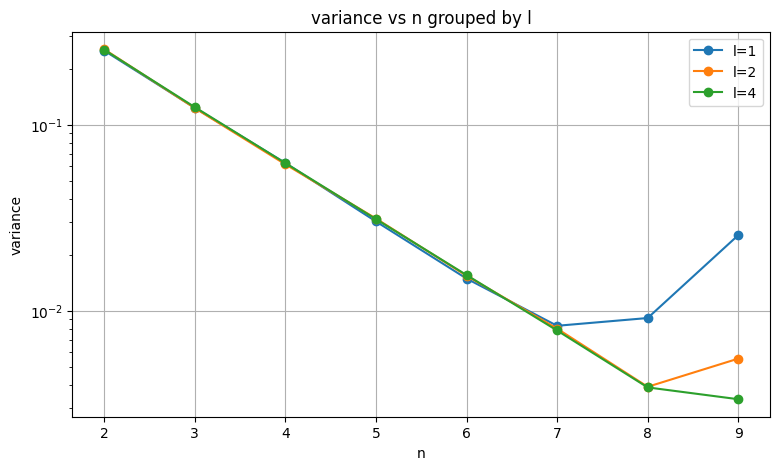

In [38]:
OVERALL_X = "n"
OVERALL_Y = "variance"
OVERALL_GROUP_BY = ["l"]  # A column, list of columns, or None

OVERALL_NS = None                # e.g. [2, 3, 4]
OVERALL_LS = [1,2,4]                # e.g. [1, 2, 4]
OVERALL_CIRCUITS = "default"          # e.g. ["multiscale_tree", "uni2"]
OVERALL_INITIAL_STATES = "sine"    # e.g. ["positive_periodic_wave"]

overall_plot_data, ax = an.plot_gradient_run_table(
    gradient_run_stats,
    x=OVERALL_X,
    y=OVERALL_Y,
    ns=OVERALL_NS,
    ls=OVERALL_LS,
    circuits=OVERALL_CIRCUITS,
    initial_states=OVERALL_INITIAL_STATES,
    group_by=OVERALL_GROUP_BY,
    kind="line",              # "line" or "scatter"
    log_x=False,
    log_y=True,
)
# overall_plot_data


## Configurable plots for individual parameters

`PARAMETERS` accepts ordinary indices (`0`, `3`), negative Python-style indices (`-1` is the last parameter), and `"mid"`. The `"mid"` selector is resolved independently for every run as the middle parameter of its middle repeated circuit layer; for even counts, the later of the two middle choices is used. Group by `parameter_selection` when comparing multiple selectors.


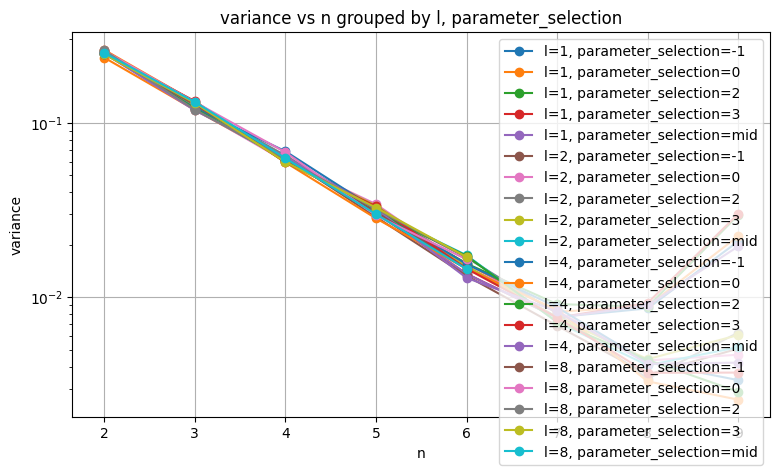

In [27]:
PARAMETER_X = "n"
PARAMETER_Y = "variance"
PARAMETERS = [0,2,3, -1, "mid"]
PARAMETER_GROUP_BY = ["l", "parameter_selection"]

PARAMETER_NS = None                # e.g. [2, 3, 4]
PARAMETER_LS = None                # e.g. [1, 2, 4]
PARAMETER_CIRCUITS = "default"          # e.g. ["multiscale_tree", "uni2"]
PARAMETER_INITIAL_STATES = "sine"    # e.g. ["positive_periodic_wave"]

parameter_plot_data, ax = an.plot_gradient_parameter_table(
    gradient_parameter_stats,
    x=PARAMETER_X,
    y=PARAMETER_Y,
    parameters=PARAMETERS,
    ns=PARAMETER_NS,
    ls=PARAMETER_LS,
    circuits=PARAMETER_CIRCUITS,
    initial_states=PARAMETER_INITIAL_STATES,
    group_by=PARAMETER_GROUP_BY,
    kind="line",                # "line" or "scatter"
    log_x=False,
    log_y=True,
)
# parameter_plot_data


## Exponential scaling fits over N

For every selected `(L, initial_state, circuit)` combination, the next cell fits variance and mean gradient norm to $y=A\,b^N$. The fit is performed as $\log y=\log A+N\log b$. If several selected runs produce the same N-point, their metric values are averaged before fitting.


,metric,l,initial_state,circuit,amplitude_A,base_b,log_base,r2_log,n_points
0,variance,1,sine,default,1.032352,0.493916,-0.705390,0.999934,5
1,variance,2,sine,default,1.015956,0.497601,-0.697956,0.999829,5
2,variance,4,sine,default,1.015520,0.498199,-0.696756,0.999974,5
3,variance,8,sine,default,1.003805,0.500335,-0.692477,0.999980,5
4,mean_gradient_norm,1,sine,default,1.630111,0.791405,-0.233946,0.982001,5
5,mean_gradient_norm,2,sine,default,1.967774,0.799449,-0.223833,0.986925,5
6,mean_gradient_norm,4,sine,default,2.491657,0.807140,-0.214259,0.986982,5
7,mean_gradient_norm,8,sine,default,3.297790,0.812425,-0.207731,0.985949,5


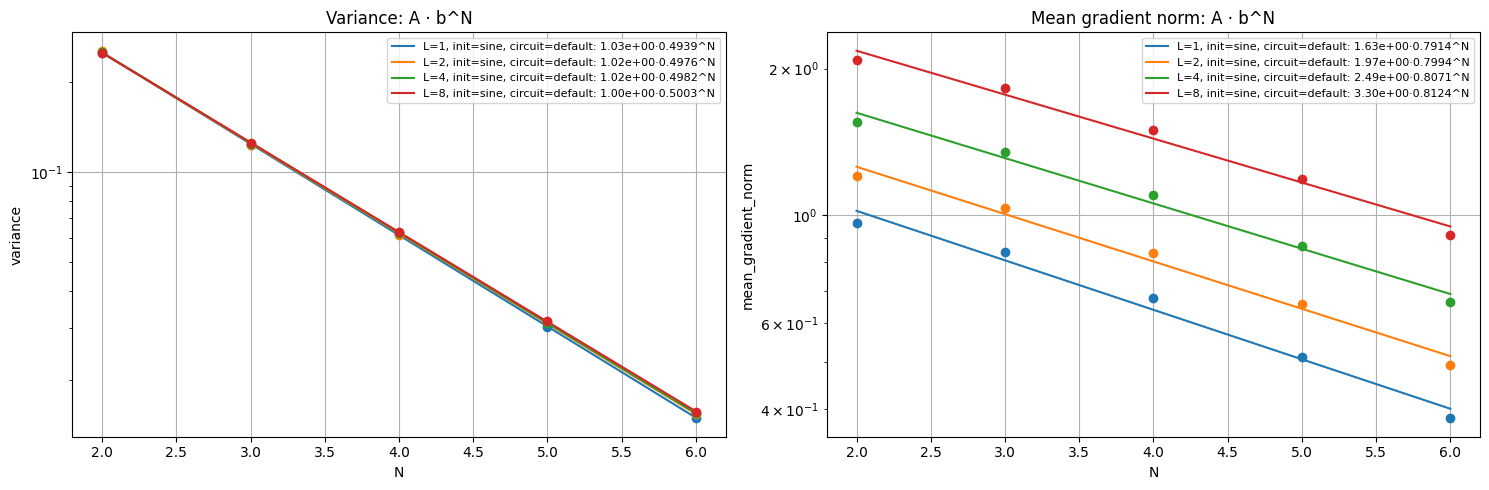

In [14]:
import pandas as pd

# Optional exact selection by full_label; leave as None to use the filters below.
FIT_RUNS = None  # e.g. ["grad_N2L1", "grad_N3L1", "grad_N4L1"]
FIT_NS = [2,3,4,5,6]  # e.g. [2, 3, 4, 5, 6]
FIT_LS = None  # e.g. [1, 2, 4]
FIT_INITIAL_STATES = "sine"  # e.g. ["positive_periodic_wave"]
FIT_CIRCUITS = "default"  # e.g. ["multiscale_tree", "uni2"]

fit_data = an.filter_gradient_table(
    gradient_run_stats,
    ns=FIT_NS,
    ls=FIT_LS,
    circuits=FIT_CIRCUITS,
    initial_states=FIT_INITIAL_STATES,
)
if FIT_RUNS is not None:
    fit_run_labels = [FIT_RUNS] if isinstance(FIT_RUNS, str) else FIT_RUNS
    fit_data = fit_data[fit_data["full_label"].isin(fit_run_labels)].copy()
if fit_data.empty:
    raise ValueError("No gradient runs remain after applying the fit filters.")

group_columns = ["l", "initial_state", "circuit"]
metrics = [("variance", "Variance"), ("mean_gradient_norm", "Mean gradient norm")]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
fit_records = []
skipped_fits = []

for ax, (metric, title) in zip(axes, metrics):
    for group_values, group in fit_data.groupby(group_columns, dropna=False, sort=True):
        points = pd.DataFrame({
            "n": pd.to_numeric(group["n"], errors="coerce"),
            metric: pd.to_numeric(group[metric], errors="coerce"),
        }).dropna()
        points = points[np.isfinite(points[metric]) & (points[metric] > 0)]
        points = points.groupby("n", as_index=False)[metric].mean().sort_values("n")

        if points["n"].nunique() < 2:
            skipped_fits.append((metric, *group_values, "fewer than two positive N-points"))
            continue

        n_values = points["n"].to_numpy(dtype=float)
        y_values = points[metric].to_numpy(dtype=float)
        log_base, log_amplitude = np.polyfit(n_values, np.log(y_values), 1)
        amplitude = float(np.exp(log_amplitude))
        base = float(np.exp(log_base))
        fitted_log_values = log_amplitude + log_base * n_values
        log_residual = np.sum((np.log(y_values) - fitted_log_values) ** 2)
        log_total = np.sum((np.log(y_values) - np.mean(np.log(y_values))) ** 2)
        r2_log = float(1 - log_residual / log_total) if log_total > 0 else np.nan

        l_value, initial_state, circuit = group_values
        group_label = f"L={l_value}, init={initial_state}, circuit={circuit}"
        n_fit = np.linspace(n_values.min(), n_values.max(), 200)
        fit_line, = ax.plot(
            n_fit,
            amplitude * base**n_fit,
            label=f"{group_label}: {amplitude:.2e}·{base:.4f}^N",
        )
        ax.scatter(n_values, y_values, color=fit_line.get_color(), zorder=3)
        fit_records.append({
            "metric": metric,
            "l": l_value,
            "initial_state": initial_state,
            "circuit": circuit,
            "amplitude_A": amplitude,
            "base_b": base,
            "log_base": float(log_base),
            "r2_log": r2_log,
            "n_points": len(n_values),
        })

    ax.set_title(f"{title}: A · b^N")
    ax.set_xlabel("N")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if ax.has_data():
        ax.legend(fontsize=8)

fig.tight_layout()
fit_results = pd.DataFrame(fit_records)
if skipped_fits:
    print("Skipped fits:")
    for skipped in skipped_fits:
        print("  ", skipped)
fit_results


## Raw gradients

The dictionaries below expose both the saved raw tensors and every reconstructed parameter-by-sweep matrix. For example, use `gradient_components[run_label]["circuit_1"][parameter_index]` or `gradient_components[run_label]["contribution_2"]`.


In [13]:
gradient_circuit_derivatives = {
    row["full_label"]: an.load_gradient_circuit_derivatives(row)
    for row in selected_gradient_runs
}
gradient_components = {
    row["full_label"]: an.load_gradient_components(row)
    for row in selected_gradient_runs
}
{run: {name: values.shape for name, values in components.items()}
 for run, components in gradient_components.items()}


{'tests_N2L1': {'current_dt': (4, 1250), 'fixed_diffusion': (4, 1250)},
 'tests_N2L2': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N2L4': {'current_dt': (10, 500), 'fixed_diffusion': (10, 500)},
 'tests_N3L1': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N3L2': {'current_dt': (9, 555), 'fixed_diffusion': (9, 555)},
 'tests_N3L4': {'current_dt': (15, 333), 'fixed_diffusion': (15, 333)},
 'tests_N4L1': {'current_dt': (8, 625), 'fixed_diffusion': (8, 625)}}

In [17]:
len(gradient_components["tests_N2L1"]["total"][0])

1250